# Brazilian E-Commerce Analytics — Olist

## Project Objective

This project analyzes the Brazilian Olist e-commerce dataset to understand sales performance, customer behavior, product performance, payment patterns, delivery performance, and customer satisfaction.

### Analytics Workflow

1. Data exploration and cleaning with Python and Pandas
2. Exploratory Data Analysis (EDA)
3. Relational data modeling in PostgreSQL
4. Business analysis using SQL
5. Interactive dashboard development with Power BI
6. Documentation and presentation through GitHub

### Key Questions

- How does revenue change over time?
- Which product categories generate the most revenue?
- Which products and sellers perform best?
- Where are customers geographically located?
- How do customers prefer to pay?
- How does delivery performance affect customer reviews?
- Which customer segments contribute the most value?

## Import our Python libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Check for current working directory 

In [9]:
Path.cwd()

WindowsPath('C:/dev/Retail-Analytics')

### Define the project data directory

In [6]:
data_dir = Path("data")

print("Data folder:", data_dir.resolve())
print("Folder exists:", data_dir.exists())

Data folder: C:\dev\Retail-Analytics\data
Folder exists: True


## Load the Datasets

The Olist dataset consists of multiple CSV files representing different parts of the e-commerce system, including customers, orders, products, sellers, payments, reviews, and geographic information.

In this step, each CSV file is loaded into a Pandas DataFrame for exploration and analysis.

In [10]:
customers = pd.read_csv(data_dir / "olist_customers_dataset.csv")
geolocation = pd.read_csv(data_dir / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(data_dir / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(data_dir / "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(data_dir / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(data_dir / "olist_orders_dataset.csv")
products = pd.read_csv(data_dir / "olist_products_dataset.csv")
sellers = pd.read_csv(data_dir / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(data_dir / "product_category_name_translation.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 3. Initial Data Exploration

Before cleaning or transforming the data, we first examine the structure and size of each dataset. This helps us understand how the tables are organized and identify which datasets will be important for later analysis.

In [11]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print(f"{name:<22} Rows: {df.shape[0]:>8,} | Columns: {df.shape[1]}")

Customers              Rows:   99,441 | Columns: 5
Geolocation            Rows: 1,000,163 | Columns: 5
Order Items            Rows:  112,650 | Columns: 7
Order Payments         Rows:  103,886 | Columns: 5
Order Reviews          Rows:   99,224 | Columns: 7
Orders                 Rows:   99,441 | Columns: 8
Products               Rows:   32,951 | Columns: 9
Sellers                Rows:    3,095 | Columns: 4
Category Translation   Rows:       71 | Columns: 2


## 4. Dataset Structure and Columns

After reviewing the size of each dataset, the next step is to examine the available columns. Understanding the columns helps identify potential primary keys, foreign keys, numerical measures, categorical variables, and relationships between tables.

In [12]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    print(df.columns.tolist())


Customers
--------------------------------------------------
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Geolocation
--------------------------------------------------
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Order Items
--------------------------------------------------
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Order Payments
--------------------------------------------------
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Order Reviews
--------------------------------------------------
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Orders
--------------------------------------------------
['order_id', 'customer_id', 'order_status', 'order_purchase_times

## 5. Preview the Data

After identifying the structure and relationships between the datasets, we preview sample records from each table to understand the values, formats, and types of information contained in the columns.

In [13]:
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head())


Customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



Order Items


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Category Translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## 6. Missing Values Analysis

Missing values can affect the accuracy and reliability of an analysis. Before cleaning the datasets, we identify the number and percentage of missing values in each column to determine which variables require attention.

In [14]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    print(f"\n{name}")
    
    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


Customers
No missing values

Geolocation
No missing values

Order Items
No missing values

Order Payments
No missing values

Order Reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

Orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Sellers
No missing values

Category Translation
No missing values


## 7. Missing Values Investigation

Missing values are not automatically removed or replaced. Their meaning is investigated first, since some missing values may represent valid business situations rather than data-quality problems.

We examine the affected datasets to understand the patterns behind the missing values before making cleaning decisions.

In [15]:
orders.loc[
    orders["order_delivered_customer_date"].isnull(),
    "order_status"
].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

### Investigating Delivered Orders with Missing Delivery Dates

Most missing delivery dates correspond to orders that were not completed. However, a small number of orders are marked as delivered despite having no recorded customer delivery date. These records are examined separately as potential data-quality issues.

In [17]:
orders.loc[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


### Investigating Missing Product Information

Several product records are missing category and descriptive information. We examine whether these missing fields occur together and determine how they may affect product-level and category-level analysis.

In [19]:
products.loc[
    products["product_category_name"].isnull()
].head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,2200.0,16.0,2.0,11.0
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.0,16.0,7.0,11.0
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.0,18.0,8.0,14.0
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.0,22.0,14.0,14.0
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,1400.0,25.0,25.0,25.0


## 8. Duplicate Records Analysis

Duplicate records can distort metrics such as revenue, order counts, customer counts, and product performance. Each dataset is checked for exact duplicate rows before further transformation.

In [20]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name:<22} Duplicate rows: {duplicates:,}")

Customers              Duplicate rows: 0
Geolocation            Duplicate rows: 261,831
Order Items            Duplicate rows: 0
Order Payments         Duplicate rows: 0
Order Reviews          Duplicate rows: 0
Orders                 Duplicate rows: 0
Products               Duplicate rows: 0
Sellers                Duplicate rows: 0
Category Translation   Duplicate rows: 0


### Investigating Geolocation Duplicates

The geolocation dataset contains a large number of exact duplicate records. Before removing them, we examine the size of the dataset, the number of unique ZIP code prefixes, and the number of unique complete records to understand the duplication pattern.

In [21]:
print(f"Total rows: {len(geolocation):,}")
print(f"Unique complete rows: {len(geolocation.drop_duplicates()):,}")
print(f"Unique ZIP code prefixes: {geolocation['geolocation_zip_code_prefix'].nunique():,}")

Total rows: 1,000,163
Unique complete rows: 738,332
Unique ZIP code prefixes: 19,015


## 9. Data Cleaning

Based on the initial data-quality assessment, cleaning decisions are made conservatively to preserve valid business records.

### Cleaning Decisions

- Exact duplicate rows in the geolocation dataset are removed.
- Missing review comments are retained because customers can submit ratings without written comments.
- Orders with missing delivery dates are retained because many represent valid non-delivered statuses such as canceled, shipped, or unavailable orders.
- Delivered orders without a recorded delivery timestamp are retained, but will be excluded from analyses that require actual delivery dates.
- Products with missing category information are retained to avoid losing valid sales transactions. Missing categories will be classified as `Unknown` where required for category-level analysis.

In [22]:
# Remove exact duplicate geolocation records
geolocation = geolocation.drop_duplicates().copy()

print(f"Geolocation rows after removing duplicates: {len(geolocation):,}")
print(f"Remaining exact duplicates: {geolocation.duplicated().sum():,}")

Geolocation rows after removing duplicates: 738,332
Remaining exact duplicates: 0


### Handling Missing Product Categories

Products with missing category information are retained because they may still be associated with valid orders and revenue. Instead of removing these records, missing category values are labeled as `Unknown` so they can remain part of the analysis.

In [23]:
products["product_category_name"] = products["product_category_name"].fillna("Unknown")

print(
    "Missing product categories:",
    products["product_category_name"].isnull().sum()
)

print(
    "Products classified as Unknown:",
    (products["product_category_name"] == "Unknown").sum()
)

Missing product categories: 0
Products classified as Unknown: 610


### Converting Date and Time Columns

Several columns contain timestamps related to purchases, approvals, shipping, delivery, and reviews. These columns are converted from text into datetime format to support time-based analysis such as monthly sales trends and delivery performance.

In [24]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_date_columns:
    orders[column] = pd.to_datetime(orders[column])

orders[order_date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

### Converting Remaining Timestamp Columns

Timestamp fields in the order items and review datasets are also converted to datetime format to ensure consistency across the analysis.

In [25]:
# Order items timestamp
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

# Review timestamps
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for column in review_date_columns:
    order_reviews[column] = pd.to_datetime(order_reviews[column])

print("Order Items:")
print(order_items["shipping_limit_date"].dtype)

print("\nOrder Reviews:")
print(order_reviews[review_date_columns].dtypes)

Order Items:
datetime64[ns]

Order Reviews:
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


## 10. Exploratory Data Analysis (EDA)

With the datasets cleaned and prepared, we now explore the business performance of the Olist marketplace. The analysis focuses on orders, revenue, customers, products, sellers, payments, delivery performance, and customer satisfaction.

### 10.1 Order Status Distribution

We begin by examining the distribution of order statuses to understand how many orders were successfully delivered, canceled, unavailable, or remain in other stages of the order lifecycle.

In [26]:
order_status_counts = orders["order_status"].value_counts()

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### 10.2 Order Completion Rate

To evaluate order fulfillment performance, we calculate the percentage of all orders that reached the `delivered` status.

In [27]:
total_orders = len(orders)
delivered_orders = (orders["order_status"] == "delivered").sum()

delivery_rate = (delivered_orders / total_orders) * 100

print(f"Total Orders: {total_orders:,}")
print(f"Delivered Orders: {delivered_orders:,}")
print(f"Delivery Rate: {delivery_rate:.2f}%")

Total Orders: 99,441
Delivered Orders: 96,478
Delivery Rate: 97.02%


### 10.3 Revenue Analysis

Revenue is analyzed using the order items dataset. We calculate the total value of products sold and examine the contribution of freight charges separately.

This provides a high-level view of the marketplace's sales activity.

In [29]:
total_product_revenue = order_items["price"].sum()
total_freight = order_items["freight_value"].sum()
total_order_value = total_product_revenue + total_freight

print(f"Product Revenue: R$ {total_product_revenue:,.2f}")
print(f"Freight Value: R$ {total_freight:,.2f}")
print(f"Total Order Value: R$ {total_order_value:,.2f}")

Product Revenue: R$ 13,591,643.70
Freight Value: R$ 2,251,909.54
Total Order Value: R$ 15,843,553.24


### 10.4 Monthly Sales Trend

To understand how marketplace activity changed over time, order-item sales are combined with order purchase dates. Monthly product sales are then calculated to identify growth patterns, seasonal changes, and periods of unusually high or low activity.

In [30]:
# Add purchase date to each order item
sales = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

# Create a month column
sales["purchase_month"] = (
    sales["order_purchase_timestamp"]
    .dt.to_period("M")
)

# Calculate monthly product sales
monthly_sales = (
    sales.groupby("purchase_month")["price"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


### 10.5 Monthly Sales Visualization

The monthly sales trend is visualized to make changes in marketplace performance easier to identify. This helps reveal periods of growth, decline, seasonality, and unusual sales activity.

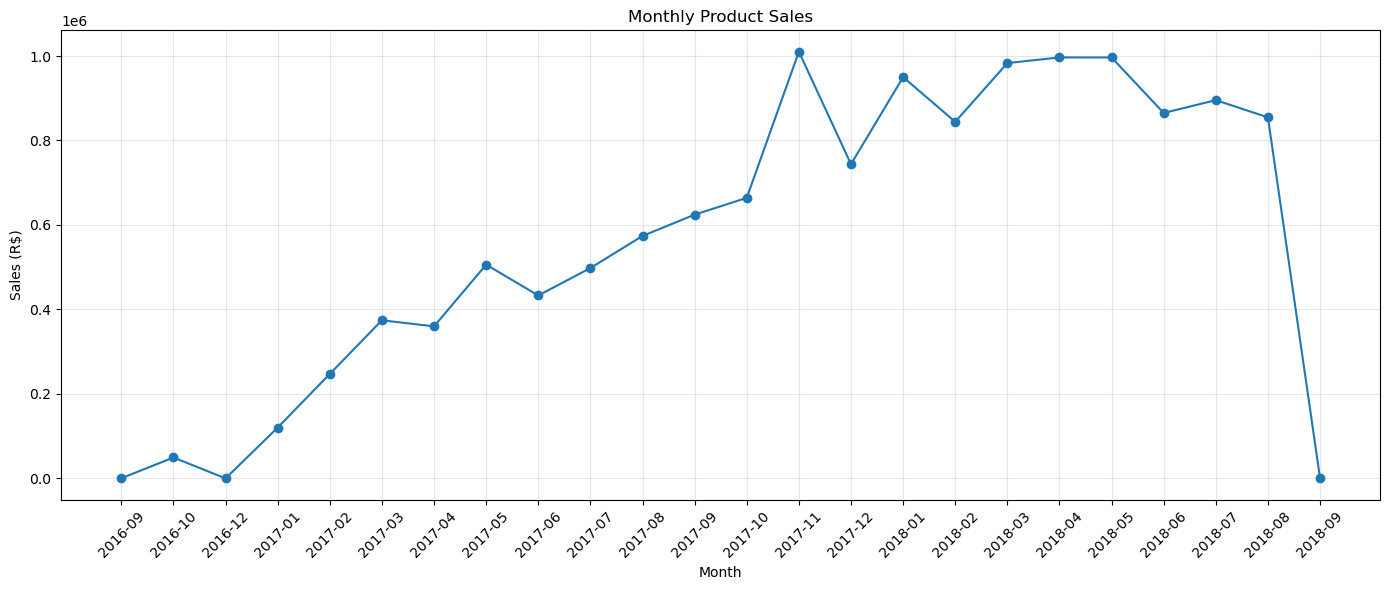

In [31]:
# Convert purchase_month to string for plotting
monthly_sales["purchase_month"] = monthly_sales["purchase_month"].astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["purchase_month"],
    monthly_sales["price"],
    marker="o"
)

plt.title("Monthly Product Sales")
plt.xlabel("Month")
plt.ylabel("Sales (R$)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 10.6 Validating the Sales Time Period

The monthly sales visualization shows a sharp decline in the final month of the dataset. Before interpreting this as a business decline, the available date range and monthly order counts are examined to determine whether the final month contains incomplete data.

In [34]:
print("First purchase:", orders["order_purchase_timestamp"].min())
print("Last purchase:", orders["order_purchase_timestamp"].max())

First purchase: 2016-09-04 21:15:19
Last purchase: 2018-10-17 17:30:18


In [33]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders["purchase_month"].value_counts().sort_index().tail(6)

purchase_month
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

### Finding

The apparent sales decline after August 2018 does not represent a normal business trend. The dataset contains only 16 orders in September 2018 and 4 orders in October 2018, compared with more than 6,000 orders per month during the preceding months.

Therefore, September and October 2018 are treated as incomplete periods and should not be used when interpreting monthly sales performance.

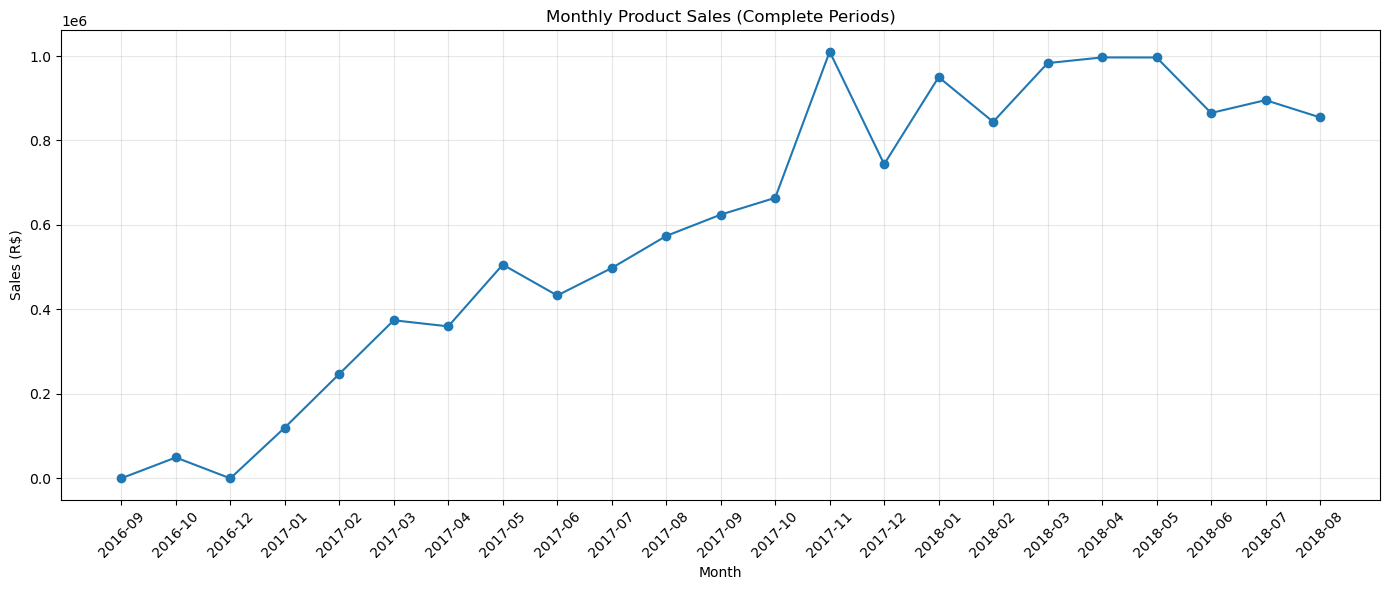

In [35]:
complete_monthly_sales = monthly_sales[
    monthly_sales["purchase_month"] <= "2018-08"
].copy()

plt.figure(figsize=(14, 6))

plt.plot(
    complete_monthly_sales["purchase_month"],
    complete_monthly_sales["price"],
    marker="o"
)

plt.title("Monthly Product Sales (Complete Periods)")
plt.xlabel("Month")
plt.ylabel("Sales (R$)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 10.7 Sales by Product Category

To identify the strongest-performing product categories, order-item sales are combined with product information using `product_id`.

The category translation table is then used to convert the original Portuguese category names into English, making the results easier to interpret.

In [36]:
category_sales = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

category_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


### 10.8 Top Product Categories by Sales

Product sales are aggregated by category to identify which categories contribute the most to marketplace sales. The top 10 categories are then ranked and visualized for comparison.

In [37]:
top_categories = (
    category_sales
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_categories

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


### 10.9 Top Product Categories Visualization

The top-performing categories are visualized using a horizontal bar chart, allowing differences in sales contribution across categories to be compared clearly.

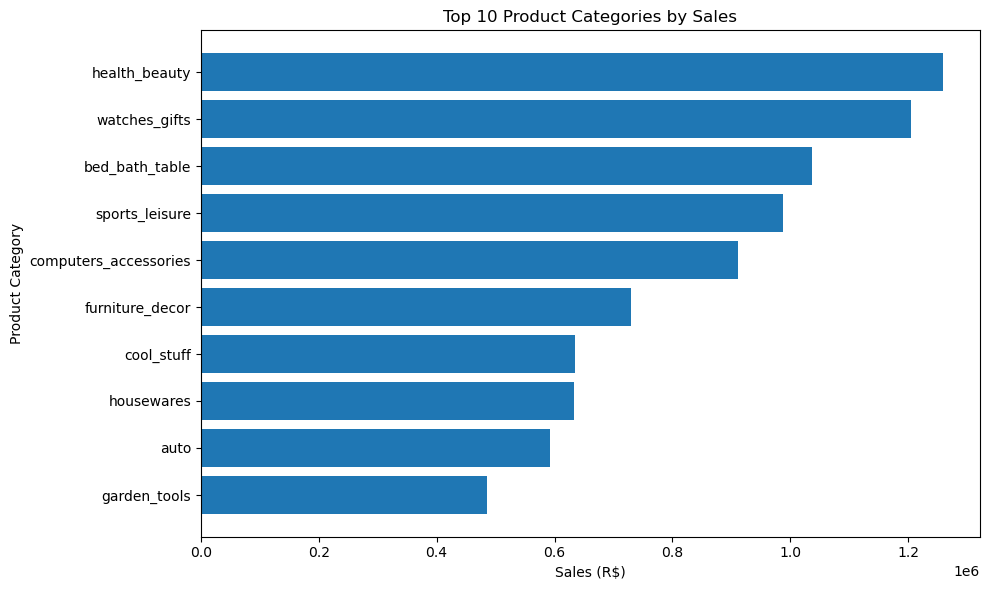

In [38]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["product_category_name_english"],
    top_categories["price"]
)

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Sales (R$)")
plt.ylabel("Product Category")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### 10.10 Customer Distribution by State

Customer locations are analyzed to identify the Brazilian states with the largest customer base and understand the geographic concentration of marketplace activity.

In [39]:
top_customer_states = (
    customers["customer_state"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_customer_states.columns = ["state", "customers"]

top_customer_states

,state,customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020



### 10.11 Customer Distribution Visualization

The geographic distribution of customers is visualized across the top 10 states by customer count. This highlights the regions with the strongest customer presence and helps identify geographic concentration within the marketplace.

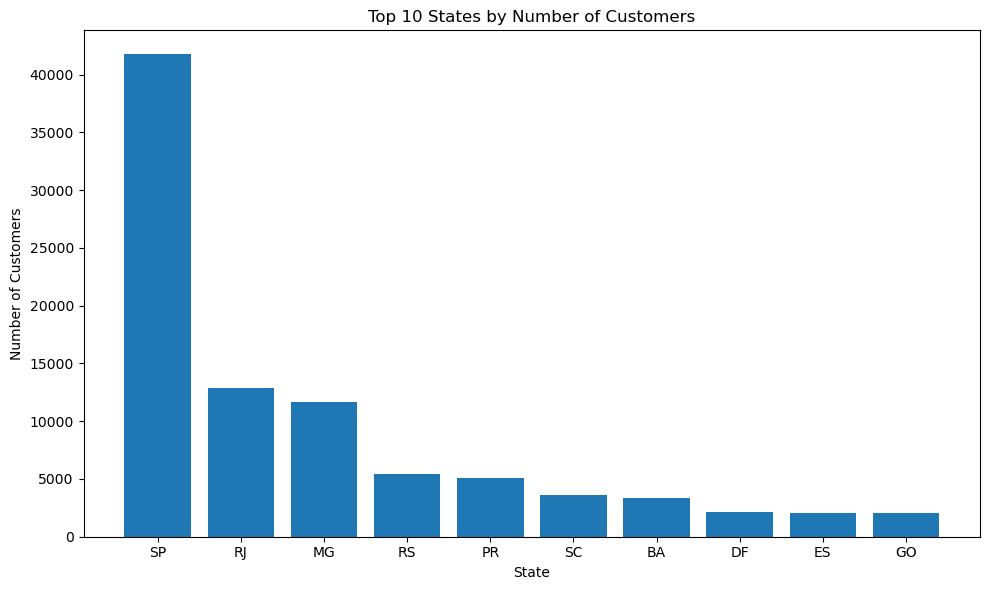

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_customer_states["state"],
    top_customer_states["customers"]
)

plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()

### 10.12 Payment Method Analysis

Customer payment behavior is analyzed to understand which payment methods are most commonly used on the marketplace. This provides insight into customer payment preferences and transaction behavior.

In [41]:
payment_methods = (
    order_payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_methods.columns = ["payment_type", "transactions"]

payment_methods

,payment_type,transactions
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


### 10.13 Payment Method Visualization

The distribution of payment transactions is visualized by payment type to compare the popularity of different payment methods.

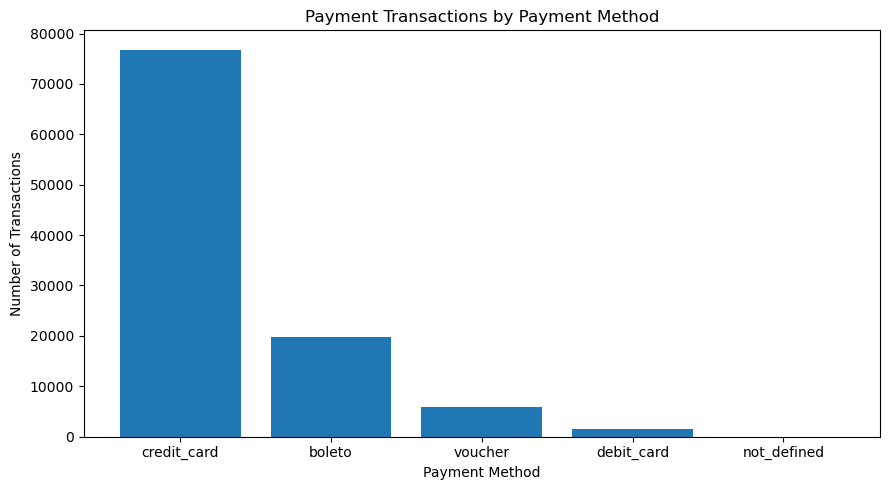

In [42]:
plt.figure(figsize=(9, 5))

plt.bar(
    payment_methods["payment_type"],
    payment_methods["transactions"]
)

plt.title("Payment Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.show()

### 10.14 Delivery Performance Analysis

Delivery performance is evaluated using completed orders with valid delivery timestamps. Actual delivery dates are compared with estimated delivery dates to determine how frequently orders arrived on time or late.

In [43]:
delivery_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

delivery_orders["delivery_days"] = (
    delivery_orders["order_delivered_customer_date"] -
    delivery_orders["order_purchase_timestamp"]
).dt.days

delivery_orders["delivery_status"] = np.where(
    delivery_orders["order_delivered_customer_date"]
    <= delivery_orders["order_estimated_delivery_date"],
    "On Time",
    "Late"
)

delivery_orders["delivery_status"].value_counts()

delivery_status
On Time    88644
Late        7826
Name: count, dtype: int64

### 10.15 Delivery Performance KPIs

Key delivery metrics are calculated to measure fulfillment efficiency, including average delivery time and the percentage of orders delivered on time.

In [44]:
average_delivery_days = delivery_orders["delivery_days"].mean()

on_time_rate = (
    (delivery_orders["delivery_status"] == "On Time").mean() * 100
)

print(f"Average Delivery Time: {average_delivery_days:.1f} days")
print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")

Average Delivery Time: 12.1 days
On-Time Delivery Rate: 91.89%


### 10.16 On-Time vs Late Deliveries

The distribution of completed deliveries is visualized to compare orders that arrived within the estimated delivery date against those that arrived late.

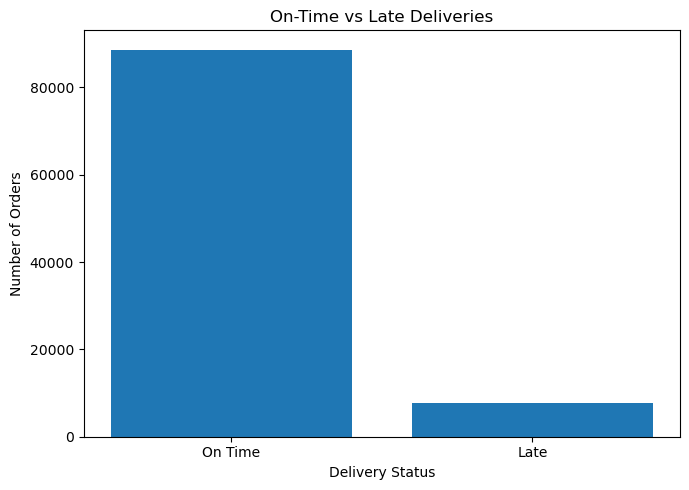

In [45]:
delivery_status_counts = delivery_orders["delivery_status"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    delivery_status_counts.index,
    delivery_status_counts.values
)

plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.show()

### 10.17 Customer Review Analysis

Customer satisfaction is analyzed using review scores submitted after orders. The distribution of ratings helps identify overall satisfaction levels and the proportion of customers reporting positive or negative experiences.

In [46]:
review_distribution = (
    order_reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

### 10.18 Review Score Visualization

Review scores are visualized from 1 to 5 stars to show the overall distribution of customer satisfaction across marketplace orders.

In [47]:
review_distribution = (
    order_reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

### 10.18 Review Score Visualization

Review scores are visualized from 1 to 5 stars to show the overall distribution of customer satisfaction across marketplace orders.

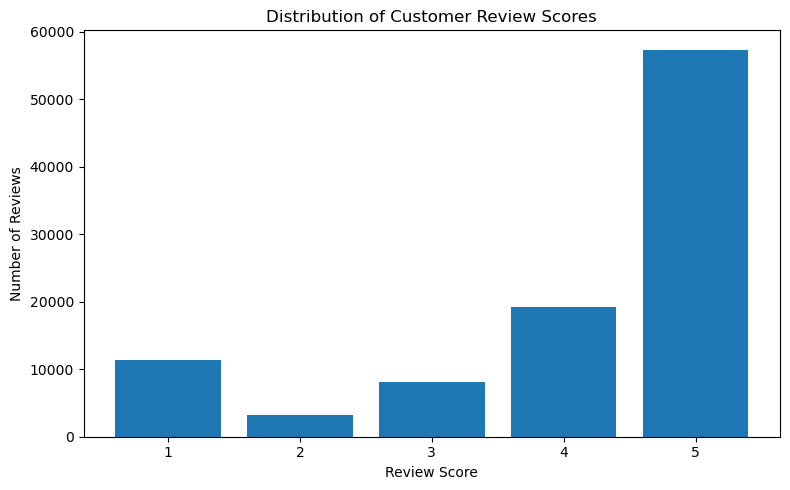

In [48]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution.index,
    review_distribution.values
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()

plt.show()

### 10.19 Customer Satisfaction KPIs

To summarize customer satisfaction, the average review score and the percentage of positive reviews are calculated. Reviews with scores of 4 or 5 are classified as positive.

In [49]:
average_review_score = order_reviews["review_score"].mean()

positive_review_rate = (
    order_reviews["review_score"].isin([4, 5]).mean() * 100
)

print(f"Average Review Score: {average_review_score:.2f} / 5")
print(f"Positive Review Rate: {positive_review_rate:.2f}%")

Average Review Score: 4.09 / 5
Positive Review Rate: 77.07%


### Interpretation

Review scores of 4 and 5 are treated as positive customer experiences. These metrics provide a high-level measure of overall customer satisfaction and complement the review-score distribution shown above.

### 10.20 Impact of Delivery Performance on Customer Satisfaction

To examine whether delivery performance is associated with customer satisfaction, delivery information is combined with customer review scores using `order_id`.

Average review scores are then compared between orders delivered on time and orders delivered late.

In [50]:
delivery_reviews = delivery_orders.merge(
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

delivery_review_scores = (
    delivery_reviews
    .groupby("delivery_status")["review_score"]
    .mean()
    .reset_index()
)

delivery_review_scores

,delivery_status,review_score
0,Late,2.566494
1,On Time,4.293718


### 10.21 Delivery Performance vs Review Score

Average customer review scores are compared between on-time and late deliveries to evaluate whether delivery performance is associated with customer satisfaction.

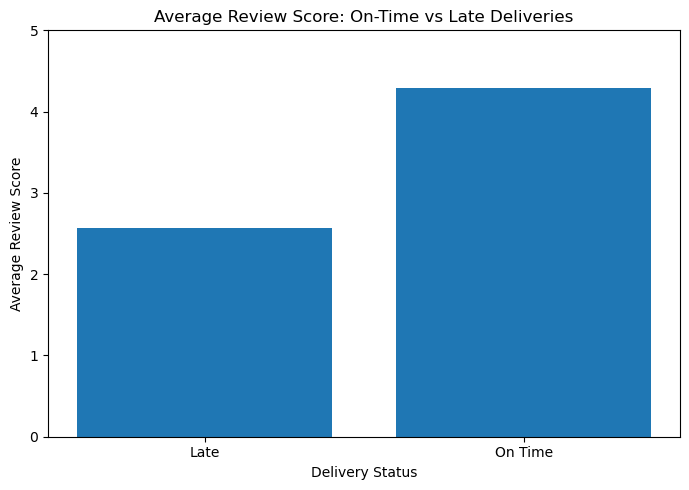

In [51]:
plt.figure(figsize=(7, 5))

plt.bar(
    delivery_review_scores["delivery_status"],
    delivery_review_scores["review_score"]
)

plt.title("Average Review Score: On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()

plt.show()

### 10.22 Top Sellers by Sales

Seller performance is analyzed by aggregating product sales for each seller. This identifies the sellers generating the highest sales value on the marketplace.

In [52]:
top_sellers = (
    order_items
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_sellers

,seller_id,price
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1,53243585a1d6dc2643021fd1853d8905,222776.05
2,4a3ca9315b744ce9f8e9374361493884,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55
9,955fee9216a65b617aa5c0531780ce60,135171.70


### 10.23 Top Sellers Visualization

The top 10 sellers are visualized by total product sales to highlight the marketplace's highest-performing sellers.

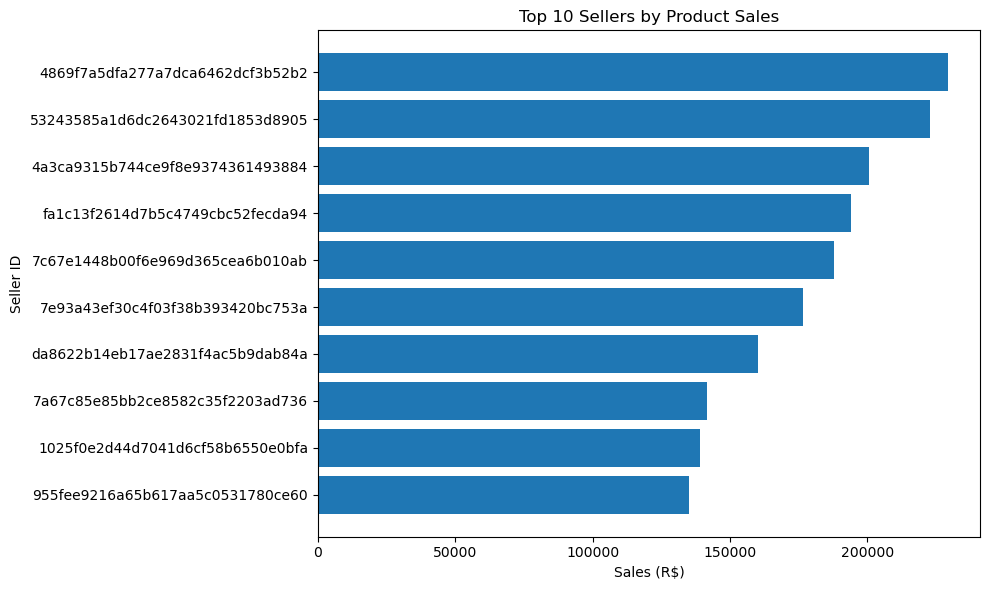

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_sellers["seller_id"],
    top_sellers["price"]
)

plt.title("Top 10 Sellers by Product Sales")
plt.xlabel("Sales (R$)")
plt.ylabel("Seller ID")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## 11. Key Findings and Business Insights

The exploratory analysis highlights several important patterns in the Olist marketplace:

- **Order Fulfillment:** The majority of orders reached the delivered status, indicating a high overall completion rate.
- **Sales Trend:** Marketplace sales increased substantially over the observed period. September and October 2018 contain very few orders and were treated as incomplete periods when interpreting monthly trends.
- **Product Performance:** Sales are concentrated among several high-performing product categories, with noticeable differences in sales contribution across categories.
- **Geographic Concentration:** Customer activity is concentrated in a relatively small number of Brazilian states, indicating strong regional differences in marketplace demand.
- **Payment Behavior:** Customers show a clear preference for particular payment methods, with some methods accounting for substantially more transactions than others.
- **Delivery Performance:** Most completed orders were delivered within their estimated delivery dates, although a portion experienced delays.
- **Customer Satisfaction:** Customer reviews are generally positive, with 4- and 5-star ratings representing a significant share of reviews.
- **Delivery and Satisfaction:** Late deliveries have a lower average review score than on-time deliveries, suggesting that delivery performance is associated with customer satisfaction.
- **Seller Performance:** Sales are unevenly distributed across sellers, with the highest-performing sellers generating substantially more sales than others.

### Conclusion

The analysis demonstrates how transactional, customer, product, payment, delivery, and review data can be combined to evaluate marketplace performance. The findings suggest that delivery reliability, geographic demand, product mix, and seller performance are important dimensions for understanding customer experience and overall marketplace activity.